# Learning PageRank, Step by Step

PageRank is the algorithm Larry Page and Sergey Brin introduced in 1998 to rank web pages for Google. The core idea:

> **A page is important if important pages link to it.**

This notebook builds PageRank from scratch with lots of visualizations:

1. The *random surfer* intuition
2. Representing a graph as a transition matrix
3. Power iteration: the basic algorithm
4. What breaks it: **dangling nodes** and **spider traps**
5. The fix: the **damping factor** and the Google matrix
6. Simulating a random surfer to check the math
7. PageRank as an **eigenvector** problem
8. How the damping factor changes the ranking
9. PageRank on a larger network
10. **Personalized PageRank**
11. Exercises

**Requirements:** `numpy`, `scipy`, `matplotlib`, `networkx` (`pip install -r requirements.txt`)

## Beginner's glossary: read this first

New to these terms? Here they are in plain language. The running example is the notebook's tiny web of 4 pages, **A, B, C, D**, that link to each other.

| Term | Plain-language meaning |
|---|---|
| **Graph** | Pages drawn as dots and links drawn as arrows. "A → B" means page A links to page B. |
| **Random surfer** | An imaginary person who clicks a random link on every page, forever. **A page's PageRank = the share of time this surfer spends on it.** |
| **Transition matrix** | A table of chances: "if I'm on page X, how likely am I to go to page Y next?" A has 2 links, so from A there's a ½ chance of going to B and ½ to C. |
| **Column-stochastic** | Each column of that table (one page's chances) adds up to 1, i.e. 100%. The surfer always goes *somewhere*. |
| **Power iteration** | Start with the surfer equally likely to be anywhere, then work out where they'll probably be after 1 click, 2 clicks, 3 clicks, and so on. |
| **Convergence** | After enough clicks the numbers stop changing. Those settled numbers are the PageRank. |
| **Dangling node (dead end)** | A page with **no links out** (e.g. a PDF). The surfer gets stuck and, in the math, all the rank "leaks away" to 0. |
| **Spider trap** | A page or group of pages that only link to themselves. The surfer can never leave, so the trap soaks up all the rank. |
| **Damping factor β ("beta")** | Google's fix: with probability β (usually 0.85 = 85%) the surfer clicks a link; otherwise they get bored and **jump to a random page**. On a dead end they always jump. |
| **Teleportation** | That random jump to any page. |
| **Google matrix** | The transition table updated to include the random jumps. The surfer can never get stuck, so there is always one clear answer. |
| **Monte Carlo simulation** | Finding an answer by running lots of random trials. Here we actually simulate the surfer clicking 200,000 times and count the visits. |
| **Eigenvector** | A list of numbers that stays the same after you apply the table to it, which is exactly the "settled" PageRank. The **dominant** eigenvector is the main one, which is the one that matters here. |
| **Eigenvalue** | A number that goes with each eigenvector. PageRank's eigenvector has eigenvalue 1, meaning "applying the table leaves it unchanged". |
| **networkx** | A popular Python library for graphs. `nx.pagerank` is its ready-made PageRank, which we use to check our code. |
| **Scale-free graph** | A network shaped like the real web, where a few "hub" pages get tons of links and most pages get very few. |
| **In-degree** | The number of links pointing **to** a page. It's the simplest popularity count. PageRank also considers *who* is linking, not just how many. |
| **Personalized PageRank** | The bored surfer always jumps back to one chosen **seed** page instead of a random page. The result measures what's important *from that page's point of view*, and is the idea behind recommendations like "people you may know". |
| **ipywidgets** | An add-on that puts sliders and buttons inside a Jupyter notebook (used for the β slider near the end). |

**The whole idea in one sentence:** PageRank imagines a random clicker who sometimes gets bored and jumps elsewhere, and ranks each page by how often that clicker ends up there.

**How to use this notebook:** run the code cells from top to bottom (**Shift + Enter** in Jupyter). Each chart illustrates one of the ideas above, so scroll back to this table whenever a term is unfamiliar.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
})
PALETTE = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3", "#937860", "#DA8BC3", "#8C8C8C"]
rng = np.random.default_rng(42)

## 1. The random surfer

Imagine someone browsing the web who, on every page, clicks one of its outgoing links **uniformly at random**. Let them do this forever.

The **PageRank of a page is the fraction of time the surfer spends on it** in the long run.

Pages with many incoming links, especially from pages that are themselves visited often, collect more of the surfer's time.

Let's start with a tiny web of 4 pages.

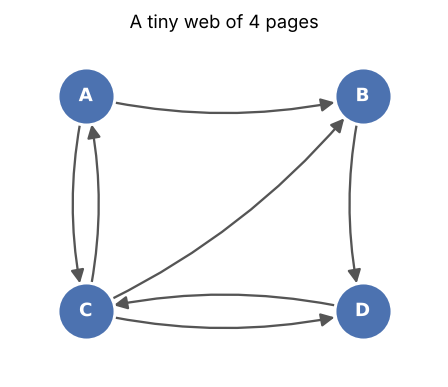

A links to ['B', 'C']
B links to ['D']
C links to ['A', 'B', 'D']
D links to ['C']


In [2]:
# A small directed graph: an edge u -> v means "page u links to page v"
edges = [
    ("A", "B"), ("A", "C"),
    ("B", "D"),
    ("C", "A"), ("C", "B"), ("C", "D"),
    ("D", "C"),
]
G = nx.DiGraph(edges)
nodes = sorted(G.nodes())
idx = {n: i for i, n in enumerate(nodes)}
N = len(nodes)

pos = {"A": (0, 1), "B": (1, 1), "C": (0, 0), "D": (1, 0)}

def draw_graph(G, pos, node_size=None, node_color=PALETTE[0], labels=None, title="", ax=None):
    # Draw a directed graph with curved arrows so that two-way links stay visible.
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 4))
    if node_size is None:
        node_size = 1400
    nx.draw_networkx_nodes(G, pos, node_size=node_size, node_color=node_color,
                           edgecolors="white", linewidths=2, ax=ax)
    nx.draw_networkx_labels(G, pos, labels=labels, font_color="white", font_weight="bold", ax=ax)
    nx.draw_networkx_edges(G, pos, node_size=node_size, arrowstyle="-|>", arrowsize=18,
                           edge_color="#555555", width=1.5, connectionstyle="arc3,rad=0.12", ax=ax)
    ax.set_title(title)
    ax.axis("off")
    ax.margins(0.2)
    return ax

draw_graph(G, pos, title="A tiny web of 4 pages")
plt.show()

for n in nodes:
    print(f"{n} links to {list(G.successors(n))}")

## 2. From graph to transition matrix

We encode the surfer's behaviour in a **transition matrix** $M$ where

$$
M_{ij} = \begin{cases} \dfrac{1}{\text{outdeg}(j)} & \text{if } j \to i \\[4pt] 0 & \text{otherwise} \end{cases}
$$

Column $j$ is the probability distribution over where a surfer on page $j$ goes next, so **every column sums to 1** (the matrix is *column-stochastic*).

If $r_t$ is the vector of probabilities that the surfer is on each page at step $t$, then

$$ r_{t+1} = M \, r_t $$

In [3]:
def transition_matrix(G, nodes):
    # Column-stochastic matrix: M[i, j] = P(go to i | currently on j).
    # Columns of pages with no out-links (dangling nodes) are left as all zeros.
    n = len(nodes)
    ix = {v: k for k, v in enumerate(nodes)}
    M = np.zeros((n, n))
    for j in nodes:
        succ = list(G.successors(j))
        for i in succ:
            M[ix[i], ix[j]] = 1 / len(succ)
    return M

M = transition_matrix(G, nodes)
print("Column sums:", M.sum(axis=0))

Column sums: [1. 1. 1. 1.]


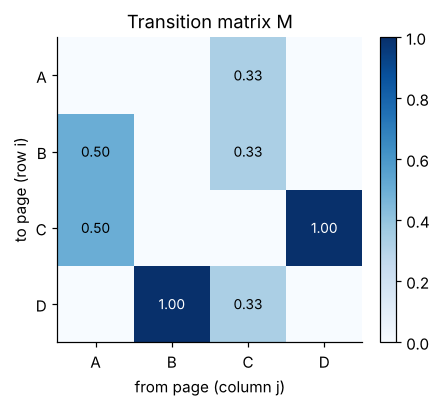

In [4]:
def show_matrix(M, labels, title, ax=None, cmap="Blues"):
    if ax is None:
        _, ax = plt.subplots(figsize=(4.2, 3.6))
    im = ax.imshow(M, cmap=cmap, vmin=0, vmax=1)
    ax.set_xticks(range(len(labels)), labels)
    ax.set_yticks(range(len(labels)), labels)
    ax.set_xlabel("from page (column j)")
    ax.set_ylabel("to page (row i)")
    ax.grid(False)
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            if M[i, j] > 0:
                ax.text(j, i, f"{M[i, j]:.2f}", ha="center", va="center",
                        color="white" if M[i, j] > 0.5 else "black", fontsize=9)
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046)
    return ax

show_matrix(M, nodes, "Transition matrix M")
plt.show()

## 3. Power iteration

Start the surfer anywhere (say, uniformly at random: $r_0 = [\tfrac14, \tfrac14, \tfrac14, \tfrac14]$) and repeatedly apply $M$.
If the sequence settles down, the limit $r^*$ satisfies

$$ r^* = M\,r^* $$

That fixed point is the PageRank vector. This simple "multiply until it stops changing" loop is called **power iteration**.

In [5]:
def power_iteration(M, r0=None, tol=1e-10, max_iter=1000):
    # Repeatedly apply r <- M r. Returns the final vector and the full history.
    n = M.shape[0]
    r = np.full(n, 1 / n) if r0 is None else np.asarray(r0, dtype=float)
    history = [r.copy()]
    for _ in range(max_iter):
        r_next = M @ r
        history.append(r_next.copy())
        if np.abs(r_next - r).sum() < tol:
            break
        r = r_next
    return r_next, np.array(history)

r, hist = power_iteration(M)
print(f"Converged after {len(hist) - 1} iterations")
for n in nodes:
    print(f"  PageRank({n}) = {r[idx[n]]:.4f}")
print("Sum =", r.sum())

Converged after 48 iterations
  PageRank(A) = 0.1250
  PageRank(B) = 0.1875
  PageRank(C) = 0.3750
  PageRank(D) = 0.3125
Sum = 0.9999999999999988


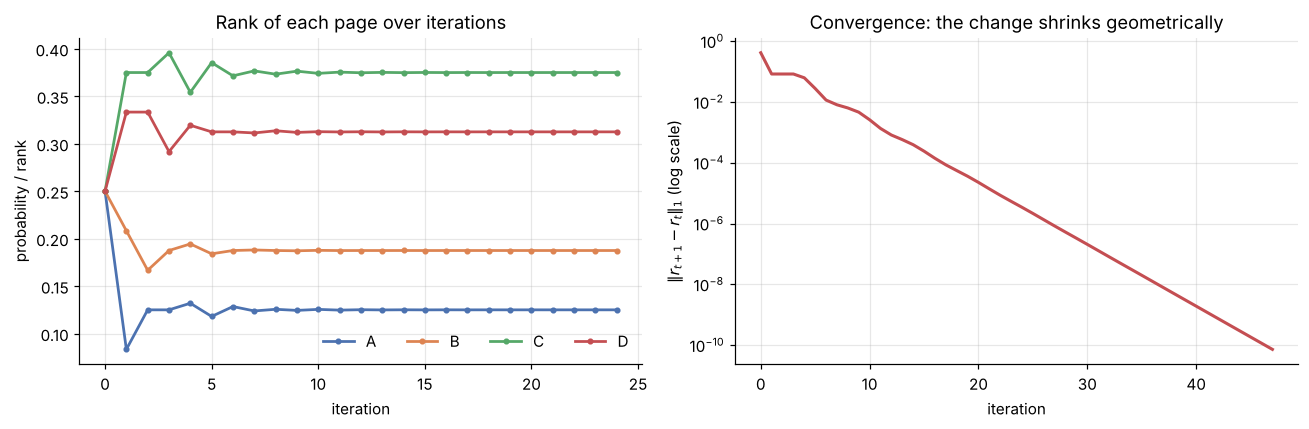

In [6]:
def plot_history(hist, labels, title, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 3.8))
    for k, lab in enumerate(labels):
        ax.plot(hist[:, k], marker="o", ms=3, lw=1.8, color=PALETTE[k % len(PALETTE)], label=lab)
    ax.set_xlabel("iteration")
    ax.set_ylabel("probability / rank")
    ax.set_title(title)
    ax.legend(frameon=False, ncol=len(labels) if len(labels) <= 6 else 2)
    return ax

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_history(hist[:25], nodes, "Rank of each page over iterations", ax=axes[0])

diffs = np.abs(np.diff(hist, axis=0)).sum(axis=1)
axes[1].semilogy(diffs, color=PALETTE[3], lw=2)
axes[1].set_xlabel("iteration")
axes[1].set_ylabel(r"$\|r_{t+1} - r_t\|_1$ (log scale)")
axes[1].set_title("Convergence: the change shrinks geometrically")
plt.tight_layout()
plt.show()

Let's see the result on the graph itself: **node size ∝ PageRank**.

Notice that **C** and **D** end up important: C gets links from A and D, and D's only link points to C, so D hands all of its rank to C.

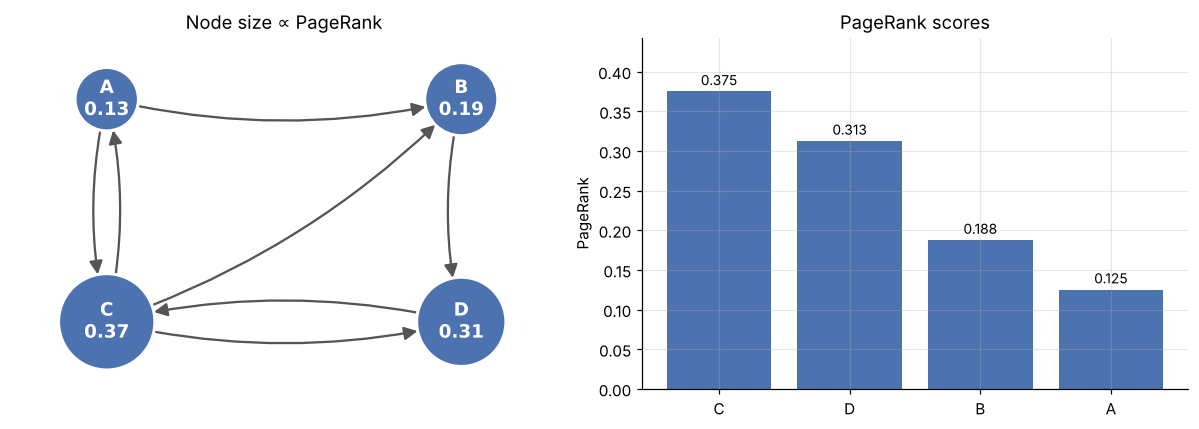

In [7]:
def rank_sizes(r, base=600, scale=9000):
    return base + scale * np.asarray(r)

def bar_ranks(r, labels, title, ax=None, color=PALETTE[0]):
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 3.5))
    order = np.argsort(r)[::-1]
    bars = ax.bar([labels[k] for k in order], r[order], color=color)
    ax.bar_label(bars, fmt="%.3f", padding=2, fontsize=9)
    ax.set_ylabel("PageRank")
    ax.set_title(title)
    ax.set_ylim(0, r.max() * 1.18)
    return ax

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
draw_graph(G, pos, node_size=rank_sizes(r), labels={n: f"{n}\n{r[idx[n]]:.2f}" for n in nodes},
           title="Node size ∝ PageRank", ax=axes[0])
bar_ranks(r, nodes, "PageRank scores", ax=axes[1])
plt.tight_layout()
plt.show()

## 4. What can go wrong?

Simple power iteration only works on "nice" graphs. Two real-world structures break it.

### 4a. Dangling nodes (dead ends)

A page with **no outgoing links** (a PDF, an image, ...) gives the surfer nowhere to go. Its column in $M$ is all zeros, so probability **leaks out** of the system each step and everything drains to 0.

Column sums: [1. 1. 1. 0.]  <- column D sums to 0


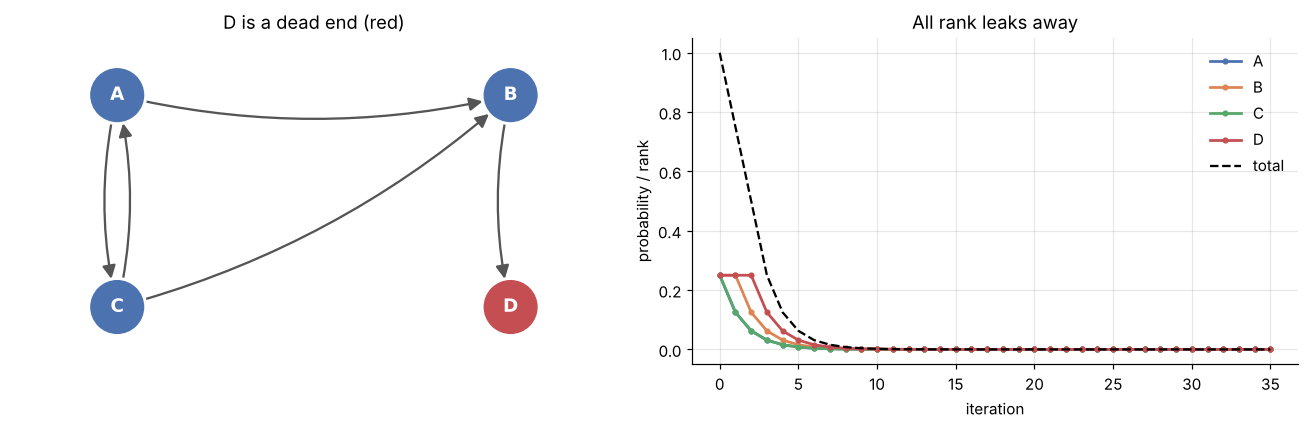

In [8]:
G_dead = nx.DiGraph([("A", "B"), ("A", "C"), ("B", "D"), ("C", "A"), ("C", "B")])  # D has no out-links
nodes_dead = sorted(G_dead.nodes())
M_dead = transition_matrix(G_dead, nodes_dead)
print("Column sums:", M_dead.sum(axis=0), " <- column D sums to 0")

r_dead, hist_dead = power_iteration(M_dead, max_iter=40)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
draw_graph(G_dead, pos, node_color=[PALETTE[3] if n == "D" else PALETTE[0] for n in nodes_dead],
           title="D is a dead end (red)", ax=axes[0])
plot_history(hist_dead, nodes_dead, "All rank leaks away", ax=axes[1])
axes[1].plot(hist_dead.sum(axis=1), "k--", lw=1.5, label="total")
axes[1].legend(frameon=False)
plt.tight_layout()
plt.show()

### 4b. Spider traps

A group of pages that link only among themselves. Once the surfer wanders in, they can never leave, so the trap **absorbs all the rank**.

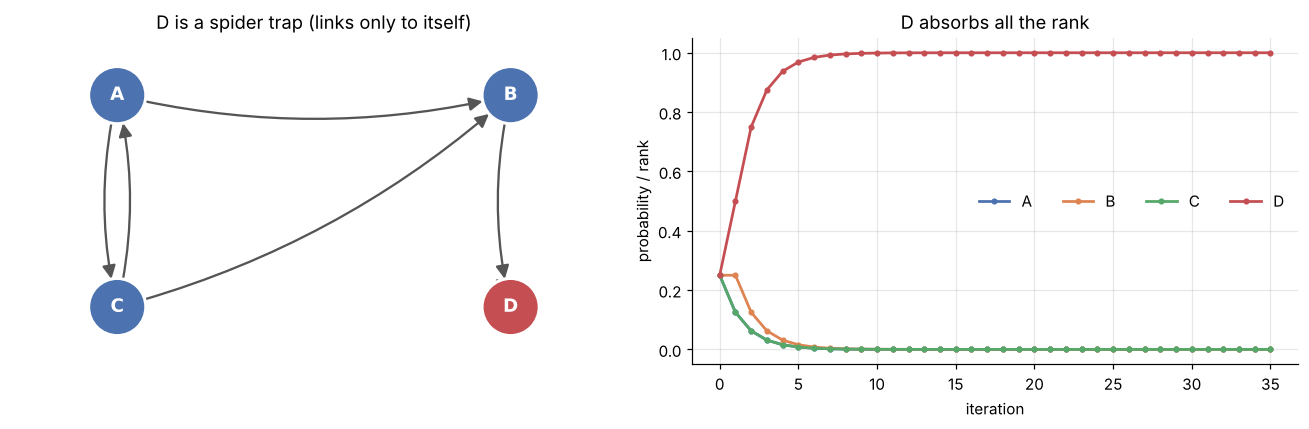

Final ranks: {'A': 0.0, 'B': 0.0, 'C': 0.0, 'D': 1.0}


In [9]:
G_trap = nx.DiGraph([("A", "B"), ("A", "C"), ("B", "D"), ("C", "A"), ("C", "B"), ("D", "D")])  # D only links to itself
nodes_trap = sorted(G_trap.nodes())
M_trap = transition_matrix(G_trap, nodes_trap)
r_trap, hist_trap = power_iteration(M_trap, max_iter=40)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
draw_graph(G_trap, pos, node_color=[PALETTE[3] if n == "D" else PALETTE[0] for n in nodes_trap],
           title="D is a spider trap (links only to itself)", ax=axes[0])
plot_history(hist_trap, nodes_trap, "D absorbs all the rank", ax=axes[1])
plt.tight_layout()
plt.show()
print("Final ranks:", {n: round(float(v), 4) for n, v in zip(nodes_trap, r_trap)})

## 5. The fix: teleportation and the damping factor

Brin and Page's fix is to change the surfer's behaviour. At each step the surfer:

- with probability $\beta$ (the **damping factor**, usually $0.85$) follows a random out-link
- with probability $1-\beta$ gets bored and **teleports** to a page chosen uniformly at random
- on a **dangling node**, always teleports

This gives the **Google matrix**:

$$
\boxed{\; G = \beta\, \hat M + (1-\beta)\,\frac{1}{N}\mathbf{1}\mathbf{1}^\top \;}
$$

where $\hat M$ is $M$ with every all-zero (dangling) column replaced by $\tfrac1N\mathbf 1$.

Equivalently, the update rule is

$$
r_{t+1} = \beta \hat M r_t + \frac{1-\beta}{N}\mathbf{1}
$$

Why it works: every entry of the Google matrix is now positive, so by the **Perron–Frobenius theorem** there is a *unique* stationary distribution and power iteration converges to it from any starting point.

In [10]:
def pagerank(G, beta=0.85, tol=1e-10, max_iter=1000, personalization=None, nodes=None):
    # PageRank by power iteration, with dangling-node handling and teleportation.
    #   beta            : damping factor (probability of following a link)
    #   personalization : optional dict {node: weight} for the teleport distribution
    # Returns (ranks as a dict, history array, node order).
    nodes = sorted(G.nodes()) if nodes is None else nodes
    n = len(nodes)
    M = transition_matrix(G, nodes)
    dangling = M.sum(axis=0) == 0

    if personalization is None:
        v = np.full(n, 1 / n)
    else:
        v = np.array([personalization.get(x, 0.0) for x in nodes], dtype=float)
        v /= v.sum()

    r = np.full(n, 1 / n)
    history = [r.copy()]
    for _ in range(max_iter):
        dangling_mass = r[dangling].sum()           # rank sitting on dead ends
        r_next = beta * (M @ r + dangling_mass * v) + (1 - beta) * v
        history.append(r_next.copy())
        if np.abs(r_next - r).sum() < tol:
            r = r_next
            break
        r = r_next
    return dict(zip(nodes, r)), np.array(history), nodes

for name, g in [("dead end", G_dead), ("spider trap", G_trap)]:
    pr, h, nd = pagerank(g)
    print(f"{name:12s} ->", {k: round(float(v), 4) for k, v in pr.items()}, f"(sum={sum(pr.values()):.4f}, {len(h)-1} iters)")

dead end     -> {'A': 0.1919, 'B': 0.2734, 'C': 0.1919, 'D': 0.3428} (sum=1.0000, 20 iters)
spider trap  -> {'A': 0.0652, 'B': 0.0929, 'C': 0.0652, 'D': 0.7766} (sum=1.0000, 28 iters)


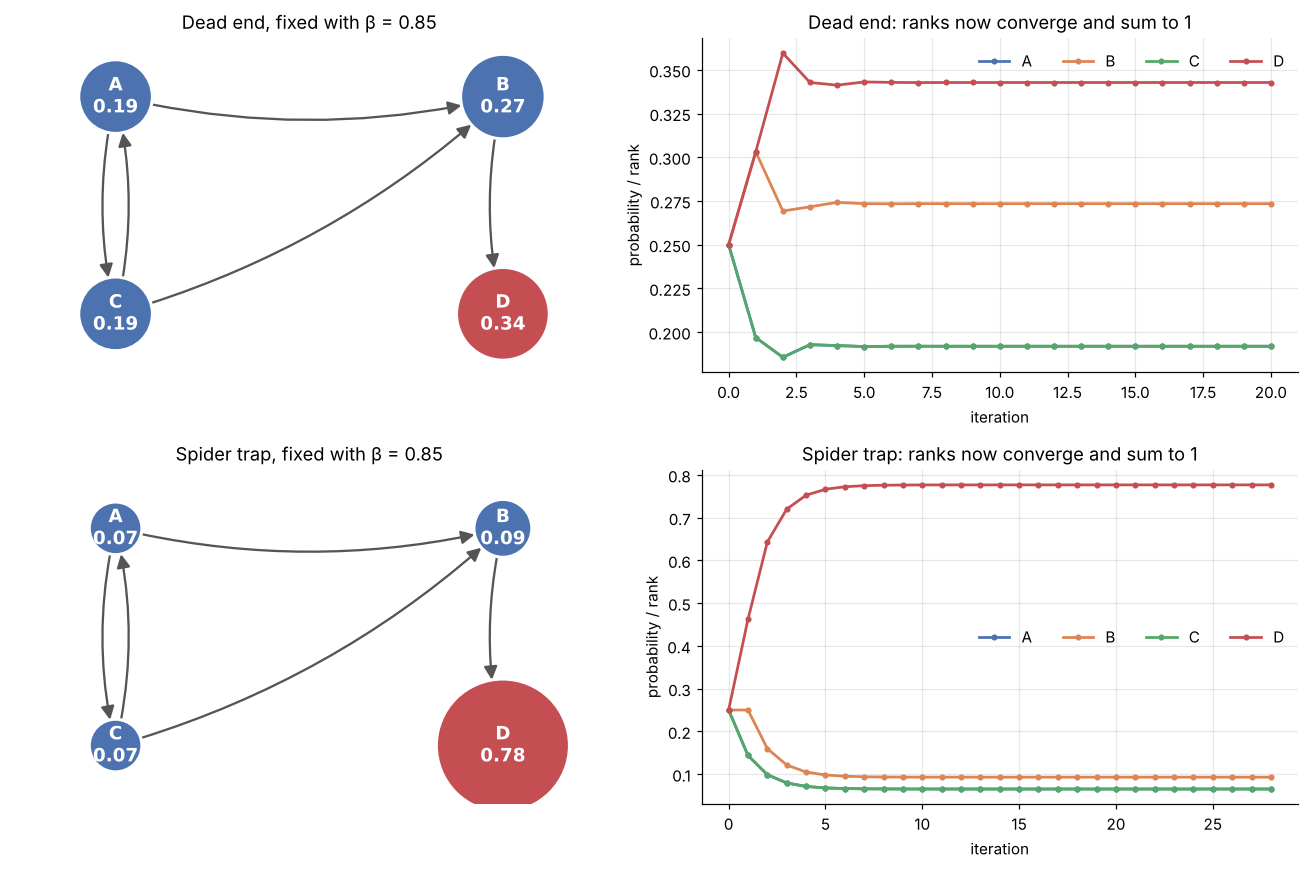

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for row, (name, g) in enumerate([("Dead end", G_dead), ("Spider trap", G_trap)]):
    pr, h, nd = pagerank(g)
    rv = np.array([pr[x] for x in nd])
    draw_graph(g, pos, node_size=rank_sizes(rv), labels={x: f"{x}\n{pr[x]:.2f}" for x in nd},
               node_color=[PALETTE[3] if x == "D" else PALETTE[0] for x in nd],
               title=f"{name}, fixed with β = 0.85", ax=axes[row, 0])
    plot_history(h, nd, f"{name}: ranks now converge and sum to 1", ax=axes[row, 1])
plt.tight_layout()
plt.show()

The Google matrix itself is dense: every page can reach every other page via teleportation. Let's look at it for the spider-trap graph.

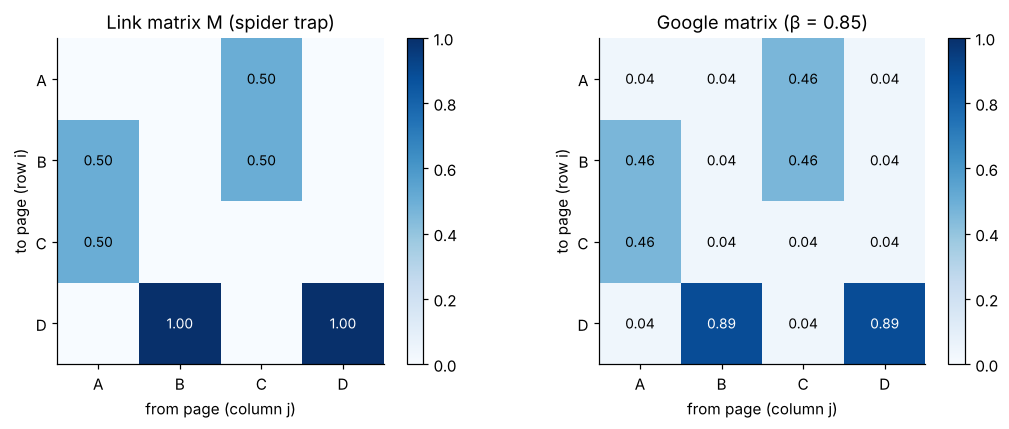

In [12]:
def google_matrix(G, nodes, beta=0.85):
    n = len(nodes)
    M = transition_matrix(G, nodes)
    M_hat = M.copy()
    M_hat[:, M.sum(axis=0) == 0] = 1 / n
    return beta * M_hat + (1 - beta) / n * np.ones((n, n))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
show_matrix(M_trap, nodes_trap, "Link matrix M (spider trap)", ax=axes[0])
show_matrix(google_matrix(G_trap, nodes_trap), nodes_trap, "Google matrix (β = 0.85)", ax=axes[1])
plt.tight_layout()
plt.show()

## 6. Checking the math: simulate a random surfer

PageRank was defined as the long-run fraction of time a random surfer spends on each page. Let's actually simulate one and compare the visit frequencies with what power iteration computed.

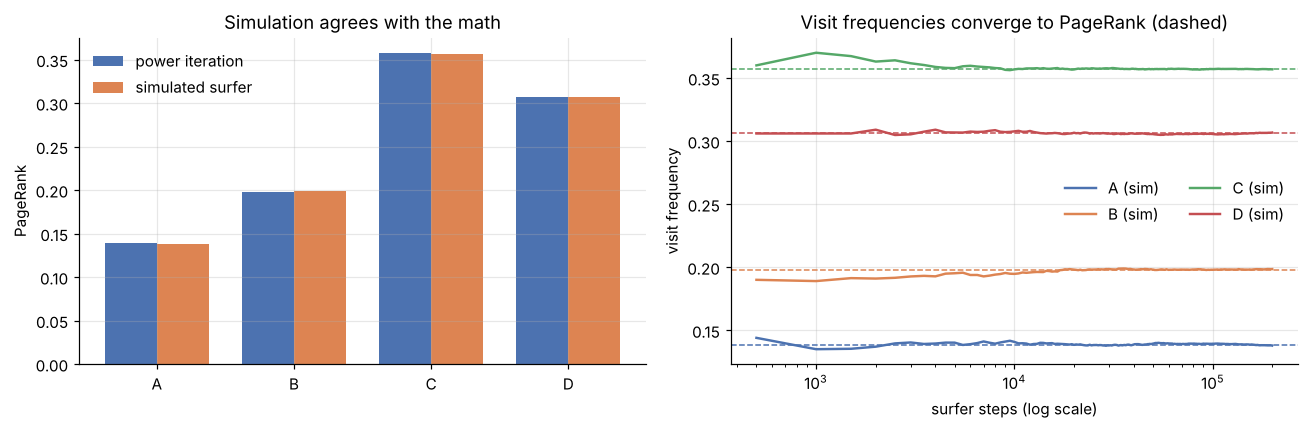

In [13]:
def simulate_surfer(G, steps=200_000, beta=0.85, seed=0):
    rng = np.random.default_rng(seed)
    nodes = sorted(G.nodes())
    succ = {n: list(G.successors(n)) for n in nodes}
    visits = {n: 0 for n in nodes}
    current = rng.choice(nodes)
    running = []
    for t in range(1, steps + 1):
        if succ[current] and rng.random() < beta:
            current = succ[current][rng.integers(len(succ[current]))]
        else:
            current = nodes[rng.integers(len(nodes))]   # teleport
        visits[current] += 1
        if t % 500 == 0:
            running.append([visits[n] / t for n in nodes])
    return {n: visits[n] / steps for n in nodes}, np.array(running), nodes

sim, running, nd = simulate_surfer(G)
pr, _, _ = pagerank(G)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
x = np.arange(len(nd))
w = 0.38
b1 = axes[0].bar(x - w / 2, [pr[n] for n in nd], w, label="power iteration", color=PALETTE[0])
b2 = axes[0].bar(x + w / 2, [sim[n] for n in nd], w, label="simulated surfer", color=PALETTE[1])
axes[0].set_xticks(x, nd)
axes[0].set_ylabel("PageRank")
axes[0].set_title("Simulation agrees with the math")
axes[0].legend(frameon=False)

steps_axis = np.arange(1, len(running) + 1) * 500
for k, n in enumerate(nd):
    axes[1].plot(steps_axis, running[:, k], color=PALETTE[k], lw=1.6, label=f"{n} (sim)")
    axes[1].axhline(pr[n], color=PALETTE[k], ls="--", lw=1)
axes[1].set_xscale("log")
axes[1].set_xlabel("surfer steps (log scale)")
axes[1].set_ylabel("visit frequency")
axes[1].set_title("Visit frequencies converge to PageRank (dashed)")
axes[1].legend(frameon=False, ncol=2)
plt.tight_layout()
plt.show()

## 7. PageRank as an eigenvector

The fixed-point equation $r = \mathcal{G}\, r$ says exactly that $r$ is an **eigenvector of the Google matrix with eigenvalue 1**.

Because $\mathcal G$ is column-stochastic with all-positive entries, 1 is its largest eigenvalue and every other eigenvalue satisfies $|\lambda| \le \beta$. That is why power iteration converges, and why the error shrinks roughly like $\beta^t$: **a smaller β converges faster**.

Let's verify with `numpy.linalg.eig`, and also compare with NetworkX's built-in `nx.pagerank`.

Eigenvalues of Google matrix: [ 1.    +0.j     -0.5326+0.j     -0.1587+0.4087j -0.1587-0.4087j]

page     ours   eigvec  networkx
   A   0.1387   0.1387    0.1387
   B   0.1976   0.1976    0.1976
   C   0.3571   0.3571    0.3571
   D   0.3066   0.3066    0.3066


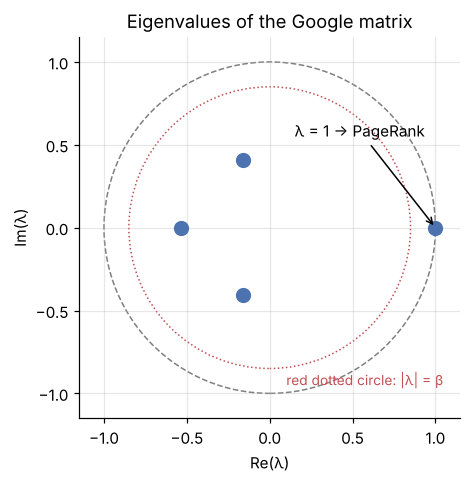

In [14]:
Gm = google_matrix(G, nodes)
eigvals, eigvecs = np.linalg.eig(Gm)
k = np.argmax(eigvals.real)
r_eig = np.abs(eigvecs[:, k].real)
r_eig /= r_eig.sum()

ours, _, _ = pagerank(G)
nx_pr = nx.pagerank(G, alpha=0.85)

print("Eigenvalues of Google matrix:", np.round(eigvals, 4))
print(f"\n{'page':>4} {'ours':>8} {'eigvec':>8} {'networkx':>9}")
for n in nodes:
    print(f"{n:>4} {ours[n]:8.4f} {r_eig[idx[n]]:8.4f} {nx_pr[n]:9.4f}")

fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.add_patch(plt.Circle((0, 0), 1, fill=False, ls="--", color="gray"))
ax.add_patch(plt.Circle((0, 0), 0.85, fill=False, ls=":", color=PALETTE[3]))
ax.scatter(eigvals.real, eigvals.imag, s=80, color=PALETTE[0], zorder=3)
ax.annotate("λ = 1 → PageRank", (1, 0), xytext=(0.15, 0.55), arrowprops=dict(arrowstyle="->"))
ax.text(0.1, -0.95, "red dotted circle: |λ| = β", color=PALETTE[3], fontsize=9)
ax.set_aspect("equal")
ax.set_xlim(-1.15, 1.15); ax.set_ylim(-1.15, 1.15)
ax.set_xlabel("Re(λ)"); ax.set_ylabel("Im(λ)")
ax.set_title("Eigenvalues of the Google matrix")
plt.show()

## 8. How does the damping factor change things?

- $\beta \to 0$: the surfer always teleports, so every page gets rank $1/N$ (the link structure is ignored).
- $\beta \to 1$: links dominate; convergence becomes slow and traps/cycles get more weight.
- $\beta = 0.85$ is Google's classic compromise.

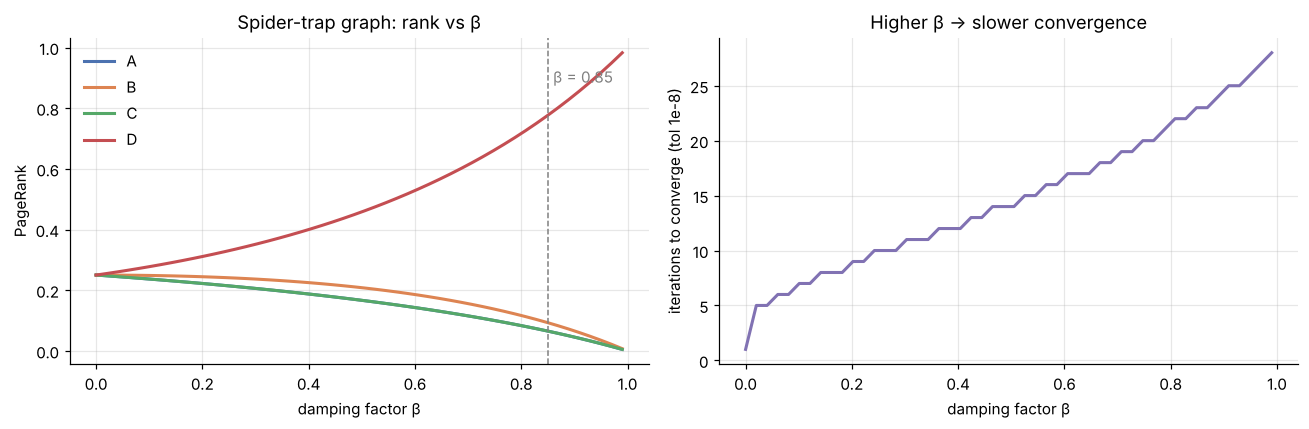

In [15]:
betas = np.linspace(0.0, 0.99, 50)
ranks_by_beta, iters_by_beta = [], []
for b in betas:
    pr_b, h_b, _ = pagerank(G_trap, beta=b, tol=1e-8)
    ranks_by_beta.append([pr_b[n] for n in nodes_trap])
    iters_by_beta.append(len(h_b) - 1)
ranks_by_beta = np.array(ranks_by_beta)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for k, n in enumerate(nodes_trap):
    axes[0].plot(betas, ranks_by_beta[:, k], color=PALETTE[k], lw=2, label=n)
axes[0].axvline(0.85, color="gray", ls="--", lw=1)
axes[0].text(0.86, 0.9 * ranks_by_beta.max(), "β = 0.85", color="gray")
axes[0].set_xlabel("damping factor β")
axes[0].set_ylabel("PageRank")
axes[0].set_title("Spider-trap graph: rank vs β")
axes[0].legend(frameon=False)

axes[1].plot(betas, iters_by_beta, color=PALETTE[4], lw=2)
axes[1].set_xlabel("damping factor β")
axes[1].set_ylabel("iterations to converge (tol 1e-8)")
axes[1].set_title("Higher β → slower convergence")
plt.tight_layout()
plt.show()

## 9. PageRank on a larger network

Now a more realistic graph: a directed **scale-free** network (like the web, a few hubs receive most links). We'll compare PageRank with simply counting incoming links (in-degree).

60 nodes, 77 edges, 6 dangling nodes, converged in 29 iterations


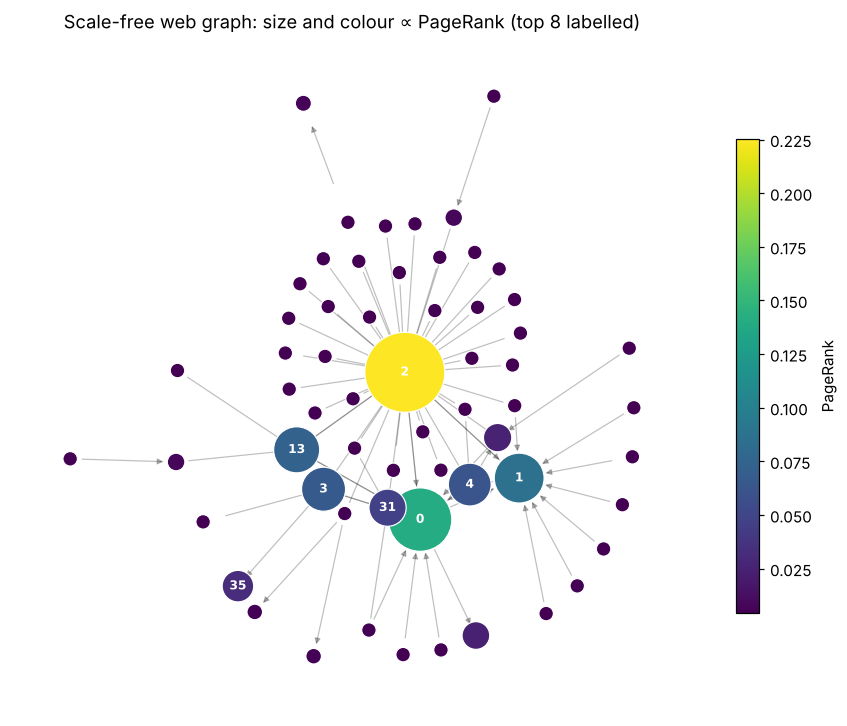

In [16]:
big = nx.DiGraph(nx.scale_free_graph(60, seed=7))   # collapse multi-edges
big.remove_edges_from(nx.selfloop_edges(big))
big = nx.relabel_nodes(big, {n: str(n) for n in big.nodes()})

pr_big, hist_big, nodes_big = pagerank(big)
r_big = np.array([pr_big[n] for n in nodes_big])
indeg = np.array([big.in_degree(n) for n in nodes_big])
print(f"{big.number_of_nodes()} nodes, {big.number_of_edges()} edges, "
      f"{sum(1 for n in big if big.out_degree(n) == 0)} dangling nodes, converged in {len(hist_big)-1} iterations")

pos_big = nx.kamada_kawai_layout(big.to_undirected())
top = sorted(pr_big, key=pr_big.get, reverse=True)[:8]

fig, ax = plt.subplots(figsize=(10, 8))
nx.draw_networkx_edges(big, pos_big, alpha=0.25, arrowsize=8, width=0.8, ax=ax,
                       node_size=200 + 12000 * r_big)
nodes_drawn = nx.draw_networkx_nodes(big, pos_big, nodelist=nodes_big, node_size=40 + 12000 * r_big,
                                     node_color=r_big, cmap="viridis", edgecolors="white", linewidths=0.8, ax=ax)
nx.draw_networkx_labels(big, pos_big, labels={n: n for n in top}, font_color="white",
                        font_size=8, font_weight="bold", ax=ax)
plt.colorbar(nodes_drawn, ax=ax, label="PageRank", shrink=0.7)
ax.set_title("Scale-free web graph: size and colour ∝ PageRank (top 8 labelled)")
ax.axis("off")
plt.show()

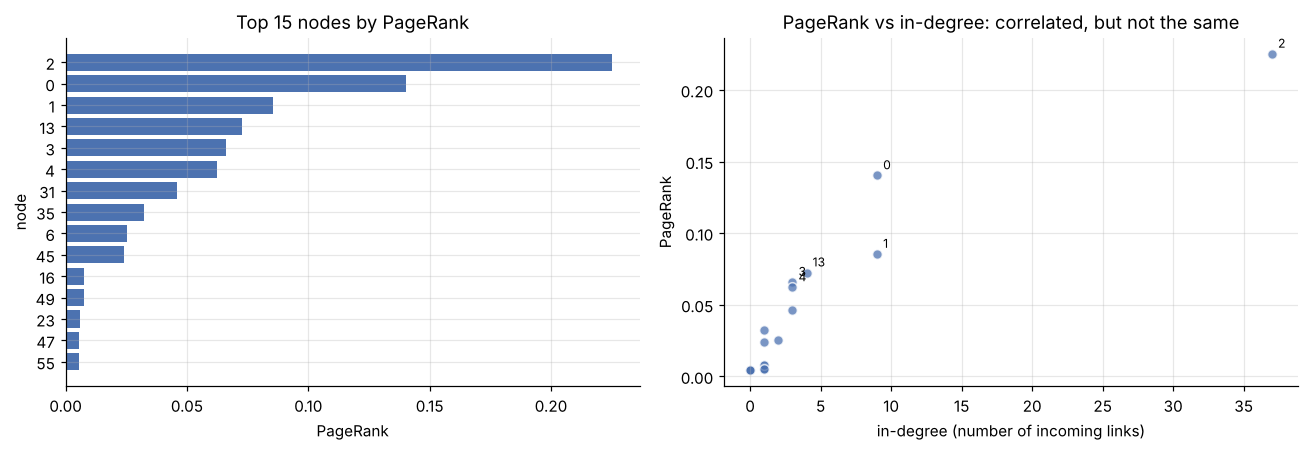

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

order = np.argsort(r_big)[::-1][:15]
axes[0].barh([nodes_big[k] for k in order][::-1], r_big[order][::-1], color=PALETTE[0])
axes[0].set_xlabel("PageRank")
axes[0].set_ylabel("node")
axes[0].set_title("Top 15 nodes by PageRank")

axes[1].scatter(indeg, r_big, s=40, color=PALETTE[0], alpha=0.75, edgecolors="white")
for k in order[:6]:
    axes[1].annotate(nodes_big[k], (indeg[k], r_big[k]), xytext=(4, 4), textcoords="offset points", fontsize=8)
axes[1].set_xlabel("in-degree (number of incoming links)")
axes[1].set_ylabel("PageRank")
axes[1].set_title("PageRank vs in-degree: correlated, but not the same")
plt.tight_layout()
plt.show()

In-degree only counts links; PageRank also weighs **who** is linking. A link from a high-rank page that has few out-links is worth far more than a link from an obscure page with hundreds of links. Points that sit above the trend in the scatter plot are pages linked to by important pages.

## 10. Personalized PageRank

Instead of teleporting to *any* page uniformly, the surfer can teleport only to a chosen set of **seed** pages. The resulting scores measure importance *relative to those seeds*. This is used for recommendations ("people you may know"), topic-sensitive search, and graph-based ML.

Just replace the uniform teleport vector $\tfrac1N\mathbf1$ with a personalization vector $v$:

$$ r = \beta \hat M r + (1-\beta)\, v $$

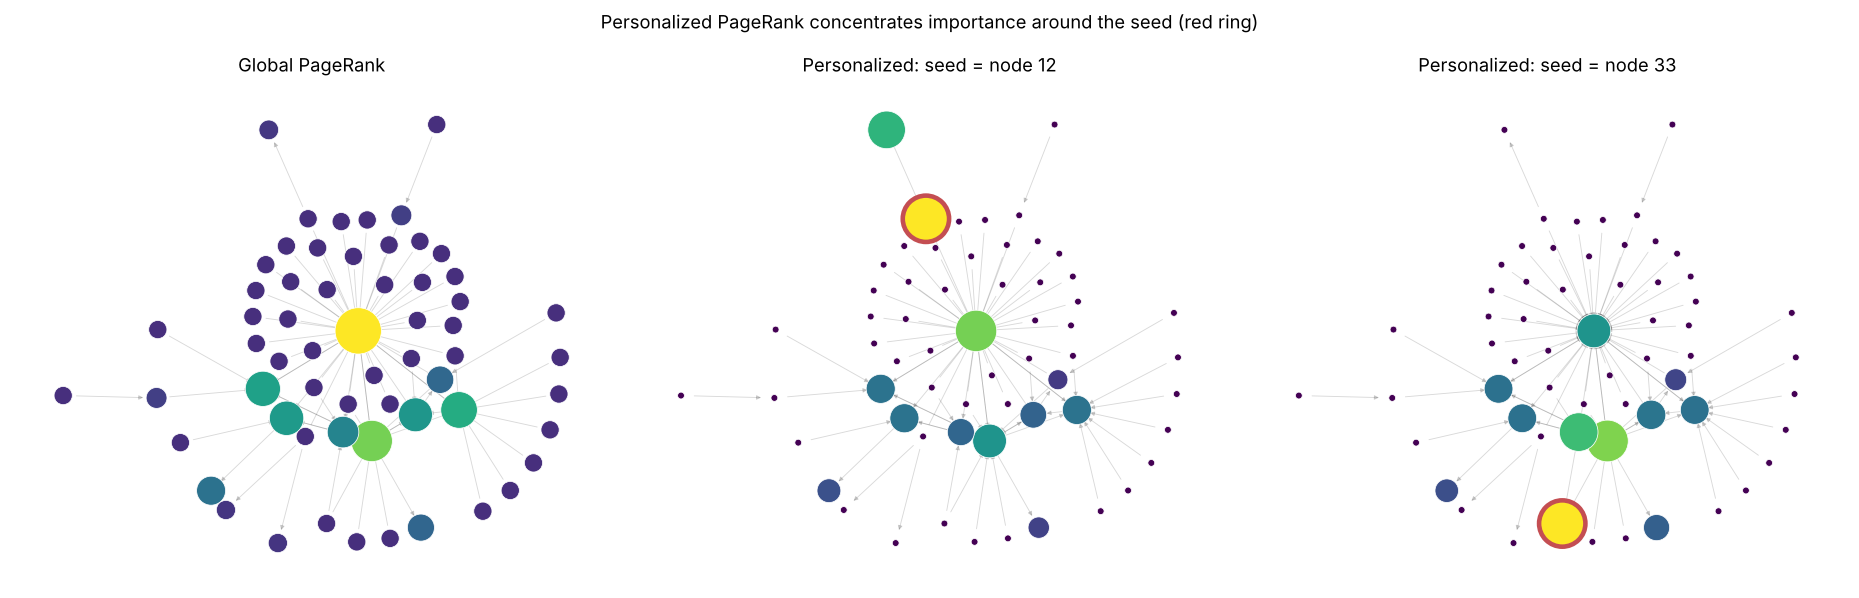

In [18]:
# Pick two seed pages that have out-links and sit far apart in the drawing
candidates = [n for n in nodes_big if big.out_degree(n) >= 2]
seed_a, seed_b = max(((a, b) for a in candidates for b in candidates),
                     key=lambda ab: np.linalg.norm(pos_big[ab[0]] - pos_big[ab[1]]))

fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))
configs = [("Global PageRank", None),
           (f"Personalized: seed = node {seed_a}", {seed_a: 1.0}),
           (f"Personalized: seed = node {seed_b}", {seed_b: 1.0})]
for ax, (title, pers) in zip(axes, configs):
    pr_p, _, _ = pagerank(big, personalization=pers)
    rp = np.array([pr_p[n] for n in nodes_big])
    rel = np.sqrt(rp / rp.max())              # sqrt keeps small scores visible
    nx.draw_networkx_edges(big, pos_big, alpha=0.15, arrowsize=6, width=0.6, ax=ax)
    nx.draw_networkx_nodes(big, pos_big, nodelist=nodes_big, node_size=20 + 900 * rel,
                           node_color=rel, cmap="viridis", vmin=0, vmax=1,
                           edgecolors="white", linewidths=0.5, ax=ax)
    if pers:
        s = next(iter(pers))
        nx.draw_networkx_nodes(big, pos_big, nodelist=[s], node_size=20 + 900 * rel[nodes_big.index(s)],
                               node_color="none", edgecolors=PALETTE[3], linewidths=3, ax=ax)
    ax.set_title(title)
    ax.axis("off")
plt.suptitle("Personalized PageRank concentrates importance around the seed (red ring)", y=0.98)
plt.tight_layout()
plt.show()

## 11. Interactive playground (optional)

If you have `ipywidgets` installed, drag the slider to see the 4-page graph's ranks change with β. Without it, the cell just prints a note.

In [19]:
try:
    from ipywidgets import interact, FloatSlider

    @interact(beta=FloatSlider(value=0.85, min=0.0, max=0.99, step=0.01, description="β"))
    def explore(beta):
        pr_i, h_i, nd_i = pagerank(G, beta=beta)
        rv = np.array([pr_i[n] for n in nd_i])
        fig, axes = plt.subplots(1, 2, figsize=(11, 4))
        draw_graph(G, pos, node_size=rank_sizes(rv), labels={n: f"{n}\n{pr_i[n]:.2f}" for n in nd_i},
                   title=f"β = {beta:.2f}  ({len(h_i)-1} iterations)", ax=axes[0])
        bar_ranks(rv, nd_i, "PageRank", ax=axes[1])
        plt.tight_layout()
        plt.show()
except ImportError:
    print("ipywidgets not installed: run `pip install ipywidgets` to enable the slider.")

ipywidgets not installed: run `pip install ipywidgets` to enable the slider.


## 12. Summary

| Concept | Key idea |
|---|---|
| Random surfer | PageRank = long-run fraction of time spent on each page |
| Transition matrix $M$ | Column $j$ spreads page $j$'s rank equally over its out-links |
| Power iteration | Repeat $r \leftarrow M r$ until it stops changing |
| Dead ends | Rank leaks out → fix by teleporting from dangling nodes |
| Spider traps | Rank gets absorbed → fix with random teleportation |
| Damping factor β | Probability of following a link (0.85 typical); also sets convergence speed |
| Eigenvector view | PageRank is the eigenvector of the Google matrix for eigenvalue 1 |
| Personalized PageRank | Teleport only to seed pages → importance relative to those seeds |

## 13. Exercises

1. Add a new page **E** to the 4-page graph that links to **A** only. Which page's rank changes the most? Why?
2. Make a page that receives links from many pages that each have hundreds of out-links. Compare its PageRank with a page that receives one link from a top-ranked page.
3. Build a **link farm**: 20 fake pages all linking to one target page. How much can you boost the target's rank? How does β affect the boost?
4. Implement PageRank with **sparse matrices** (`scipy.sparse`) and run it on a graph with 100,000 nodes.
5. Load a real network (for example `nx.karate_club_graph()` or a citation graph) and compare PageRank, in-degree and betweenness centrality.
6. Prove that $\sum_i r_i$ stays equal to 1 after each step of the damped update.